In [1]:
# Import the dependencies
import pandas as pd
import numpy as np
import datetime

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# ORM Stuff
from sqlalchemy import create_engine, inspect, text, func
from sqlalchemy.orm import Session
from sqlalchemy.ext.automap import automap_base

In [2]:
import psycopg2

In [21]:
USERNAME = "postgres"
PASSWORD = "postgres"
HOST = "localhost"
PORT = 5432
DATABASE = "Project_2_DB"
connection_str = f"postgresql://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"

# Create Engine
engine = create_engine(connection_str)

In [19]:
# Create the inspector and connect it to the engine
inspector = inspect(engine)

# Collect the names of tables within the database
tables = inspector.get_table_names()

# Using the inspector to print the column names within the 'dow' table and its types
for table in tables:
    print(table)
    print("--------")
    columns = inspector.get_columns(table)
    for column in columns:
        print(column["name"], column["type"])

    print()

contacts
--------
contact_id INTEGER
first_name VARCHAR(20)
last_name VARCHAR(20)
email VARCHAR(60)

campaign
--------
cf_id INTEGER
contact_id INTEGER
company_name VARCHAR(50)
description VARCHAR(55)
goal INTEGER
pledged INTEGER
outcome VARCHAR(10)
backers_count INTEGER
country VARCHAR(2)
currency VARCHAR(3)
launch_date DATE
end_date DATE
category_id VARCHAR(5)
subcategory_id VARCHAR(8)

categories
--------
category_id VARCHAR(5)
category VARCHAR(25)

subcategories
--------
subcategory_id VARCHAR(8)
subcategory VARCHAR(25)



In [5]:
category_df = pd.read_csv('Resources/category.csv')
category_df.head()

,category_id,category
0,cat1,food
1,cat2,music
2,cat3,technology
3,cat4,theater
4,cat5,film & video


In [6]:
category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category_id  9 non-null      object
 1   category     9 non-null      object
dtypes: object(2)
memory usage: 272.0+ bytes


In [8]:
# Write to SQL (NOTE I AM USING con=engine) THIS IS WHAT WORKS APPARENTLY WHEN WRITING OUT DATA
category_df.to_sql(name="categories", con=engine, index=False, if_exists="append", method="multi")

IntegrityError: (psycopg2.errors.UniqueViolation) duplicate key value violates unique constraint "pk_categories"
DETAIL:  Key (category_id)=(cat1) already exists.

[SQL: INSERT INTO categories (category_id, category) VALUES (%(category_id_m0)s, %(category_m0)s), (%(category_id_m1)s, %(category_m1)s), (%(category_id_m2)s, %(category_m2)s), (%(category_id_m3)s, %(category_m3)s), (%(category_id_m4)s, %(category_m4)s), (%(category_id_m5)s, %(category_m5)s), (%(category_id_m6)s, %(category_m6)s), (%(category_id_m7)s, %(category_m7)s), (%(category_id_m8)s, %(category_m8)s)]
[parameters: {'category_id_m0': 'cat1', 'category_m0': 'food', 'category_id_m1': 'cat2', 'category_m1': 'music', 'category_id_m2': 'cat3', 'category_m2': 'technology', 'category_id_m3': 'cat4', 'category_m3': 'theater', 'category_id_m4': 'cat5', 'category_m4': 'film & video', 'category_id_m5': 'cat6', 'category_m5': 'publishing', 'category_id_m6': 'cat7', 'category_m6': 'games', 'category_id_m7': 'cat8', 'category_m7': 'p

In [9]:
sub_category_df = pd.read_csv('Resources/subcategory.csv')
sub_category_df.head()

,subcategory_id,subcategory
0,subcat1,food trucks
1,subcat2,rock
2,subcat3,web
3,subcat4,plays
4,subcat5,documentary


In [10]:
sub_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   subcategory_id  24 non-null     object
 1   subcategory     24 non-null     object
dtypes: object(2)
memory usage: 512.0+ bytes


In [11]:
# Write to SQL (NOTE I AM USING con=engine) THIS IS WHAT WORKS APPARENTLY WHEN WRITING OUT DATA
sub_category_df.to_sql(name="subcategories", con=engine, index=False, if_exists="append", method="multi")

IntegrityError: (psycopg2.errors.UniqueViolation) duplicate key value violates unique constraint "pk_subcategories"
DETAIL:  Key (subcategory_id)=(subcat1) already exists.

[SQL: INSERT INTO subcategories (subcategory_id, subcategory) VALUES (%(subcategory_id_m0)s, %(subcategory_m0)s), (%(subcategory_id_m1)s, %(subcategory_m1)s), (%(subcategory_id_m2)s, %(subcategory_m2)s), (%(subcategory_id_m3)s, %(subcategory_m3)s), (%(subcategory_id_m4)s, %(subcategory_m4)s), (%(subcategory_id_m5)s, %(subcategory_m5)s), (%(subcategory_id_m6)s, %(subcategory_m6)s), (%(subcategory_id_m7)s, %(subcategory_m7)s), (%(subcategory_id_m8)s, %(subcategory_m8)s), (%(subcategory_id_m9)s, %(subcategory_m9)s), (%(subcategory_id_m10)s, %(subcategory_m10)s), (%(subcategory_id_m11)s, %(subcategory_m11)s), (%(subcategory_id_m12)s, %(subcategory_m12)s), (%(subcategory_id_m13)s, %(subcategory_m13)s), (%(subcategory_id_m14)s, %(subcategory_m14)s), (%(subcategory_id_m15)s, %(subcategory_m15)s), (%(subcategory_id_m16)s, %

In [12]:
contacts_df = pd.read_csv('Resources/contacts.csv')
contacts_df.head()

,contact_id,first_name,last_name,email
0,4661,Cecilia,Velasco,cecilia.velasco@rodrigues.fr
1,3765,Mariana,Ellis,mariana.ellis@rossi.org
2,4187,Sofie,Woods,sofie.woods@riviere.com
3,4941,Jeanette,Iannotti,jeanette.iannotti@yahoo.com
4,2199,Samuel,Sorgatz,samuel.sorgatz@gmail.com


In [13]:
contacts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   contact_id  1000 non-null   int64 
 1   first_name  1000 non-null   object
 2   last_name   1000 non-null   object
 3   email       1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB


In [14]:
# Write to SQL (NOTE I AM USING con=engine) THIS IS WHAT WORKS APPARENTLY WHEN WRITING OUT DATA
contacts_df.to_sql(name="contacts", con=engine, index=False, if_exists="append", method="multi")

IntegrityError: (psycopg2.errors.UniqueViolation) duplicate key value violates unique constraint "pk_contacts"
DETAIL:  Key (contact_id)=(4661) already exists.

[SQL: INSERT INTO contacts (contact_id, first_name, last_name, email) VALUES (%(contact_id_m0)s, %(first_name_m0)s, %(last_name_m0)s, %(email_m0)s), (%(contact_id_m1)s, %(first_name_m1)s, %(last_name_m1)s, %(email_m1)s), (%(contact_id_m2)s, %(first_name_m2)s, %(last_name_m2)s, %(email_m2)s), (%(contact_id_m3)s, %(first_name_m3)s, %(last_name_m3)s, %(email_m3)s), (%(contact_id_m4)s, %(first_name_m4)s, %(last_name_m4)s, %(email_m4)s), (%(contact_id_m5)s, %(first_name_m5)s, %(last_name_m5)s, %(email_m5)s), (%(contact_id_m6)s, %(first_name_m6)s, %(last_name_m6)s, %(email_m6)s), (%(contact_id_m7)s, %(first_name_m7)s, %(last_name_m7)s, %(email_m7)s), (%(contact_id_m8)s, %(first_name_m8)s, %(last_name_m8)s, %(email_m8)s), (%(contact_id_m9)s, %(first_name_m9)s, %(last_name_m9)s, %(email_m9)s), (%(contact_id_m10)s, %(first_name_m10)s, %

In [15]:
campaign_df = pd.read_csv('Resources/campaign.csv')
campaign_df.head()

,cf_id,contact_id,company_name,description,goal,pledged,outcome,backers_count,country,currency,launch_date,end_date,category_id,subcategory_id
0,147,4661,"Baldwin, Riley and Jackson",Pre-emptive tertiary standardization,100.0,0.0,failed,0,CA,CAD,2020-02-13 06:00:00,2021-03-01 06:00:00,cat1,subcat1
1,1621,3765,Odom Inc,Managed bottom-line architecture,1400.0,14560.0,successful,158,US,USD,2021-01-25 06:00:00,2021-05-25 05:00:00,cat2,subcat2
2,1812,4187,"Melton, Robinson and Fritz",Function-based leadingedge pricing structure,108400.0,142523.0,successful,1425,AU,AUD,2020-12-17 06:00:00,2021-12-30 06:00:00,cat3,subcat3
3,2156,4941,"Mcdonald, Gonzalez and Ross",Vision-oriented fresh-thinking conglomeration,4200.0,2477.0,failed,24,US,USD,2021-10-21 05:00:00,2022-01-17 06:00:00,cat2,subcat2
4,1365,2199,Larson-Little,Proactive foreground core,7600.0,5265.0,failed,53,US,USD,2020-12-21 06:00:00,2021-08-23 05:00:00,cat4,subcat4


In [16]:
campaign_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cf_id           1000 non-null   int64  
 1   contact_id      1000 non-null   int64  
 2   company_name    1000 non-null   object 
 3   description     1000 non-null   object 
 4   goal            1000 non-null   float64
 5   pledged         1000 non-null   float64
 6   outcome         1000 non-null   object 
 7   backers_count   1000 non-null   int64  
 8   country         1000 non-null   object 
 9   currency        1000 non-null   object 
 10  launch_date     1000 non-null   object 
 11  end_date        1000 non-null   object 
 12  category_id     1000 non-null   object 
 13  subcategory_id  1000 non-null   object 
dtypes: float64(2), int64(3), object(9)
memory usage: 109.5+ KB


In [17]:
# Write to SQL (NOTE I AM USING con=engine) THIS IS WHAT WORKS APPARENTLY WHEN WRITING OUT DATA
campaign_df.to_sql(name="campaign", con=engine, index=False, if_exists="append", method="multi")

IntegrityError: (psycopg2.errors.UniqueViolation) duplicate key value violates unique constraint "pk_campaign"
DETAIL:  Key (cf_id)=(147) already exists.

[SQL: INSERT INTO campaign (cf_id, contact_id, company_name, description, goal, pledged, outcome, backers_count, country, currency, launch_date, end_date, category_id, subcategory_id) VALUES (%(cf_id_m0)s, %(contact_id_m0)s, %(company_name_m0)s, %(description_m0)s, %(goal_m0)s, %(pledged_m0)s, %(outcome_m0)s, %(backers_count_m0)s, %(country_m0)s, %(currency_m0)s, %(launch_date_m0)s, %(end_date_m0)s, %(category_id_m0)s, %(subcategory_id_m0)s), (%(cf_id_m1)s, %(contact_id_m1)s, %(company_name_m1)s, %(description_m1)s, %(goal_m1)s, %(pledged_m1)s, %(outcome_m1)s, %(backers_count_m1)s, %(country_m1)s, %(currency_m1)s, %(launch_date_m1)s, %(end_date_m1)s, %(category_id_m1)s, %(subcategory_id_m1)s), (%(cf_id_m2)s, %(contact_id_m2)s, %(company_name_m2)s, %(description_m2)s, %(goal_m2)s, %(pledged_m2)s, %(outcome_m2)s, %(backers_count_m2)s, 

In [34]:
query = """
SELECT 
    categories.category AS category_name,
    SUM(campaign.pledged) AS total_pledged
FROM 
    campaign
JOIN 
    categories ON campaign.category_id = categories.category_id
GROUP BY 
    categories.category
ORDER BY 
    total_pledged DESC;
"""

try:
    # Execute the query and load results into a DataFrame
    df = pd.read_sql_query(query, engine)
    print(df)
except Exception as e:
    print("Error:", e)

  category_name  total_pledged
0       theater       15763227
1  film & video        7510076
2         music        7480097
3    technology        3833725
4    publishing        3149827
5         games        2015817
6          food        1735179
7   photography        1223931
8    journalism          36176


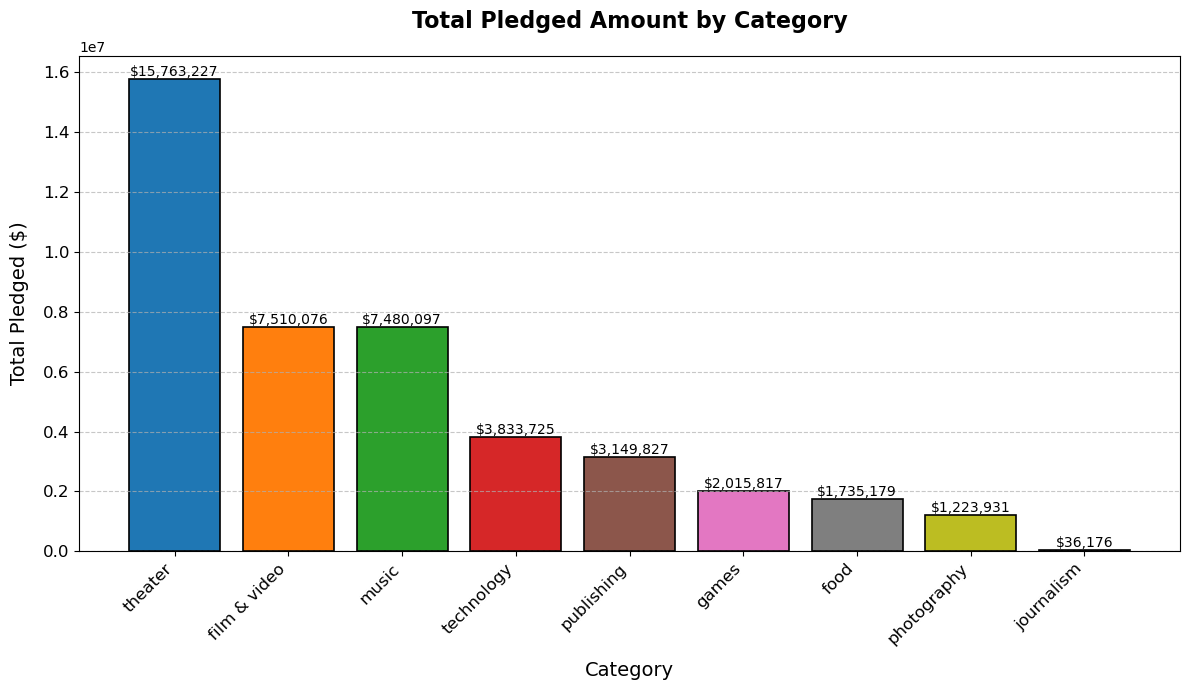

In [35]:
# Generate a color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(df['category_name'])))

# Bar chart of total pledged by category
plt.figure(figsize=(12, 7))

# Customizing the bar plot with colors
bars = plt.bar(
    df['category_name'], 
    df['total_pledged'], 
    color=colors,  # Assign the color palette
    edgecolor='black', 
    linewidth=1.2
)

# Add value labels to each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height, 
        f'${height:,.0f}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Customizing titles and labels
plt.title('Total Pledged Amount by Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=14, labelpad=10)
plt.ylabel('Total Pledged ($)', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Adding gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)


# Adjust layout for better spacing
plt.tight_layout()

# Save the chart as an image file
plt.savefig('total_pledged_by_category.png', dpi=300, bbox_inches='tight')

# Display the chart
plt.show()

In [39]:
query = """
SELECT 
    c.country AS country,
    cat.category AS category_name,
    SUM(c.pledged) AS total_pledged
FROM 
    campaign c
JOIN 
    categories cat ON c.category_id = cat.category_id
GROUP BY 
    c.country, cat.category
ORDER BY 
    c.country, total_pledged DESC;
"""

try:
    # Execute the query and load results into a DataFrame
    df = pd.read_sql_query(query, engine)
    print(df)
except Exception as e:
    print("Error:", e)

   country category_name  total_pledged
0       AU    technology         728462
1       AU       theater         545014
2       AU  film & video         213806
3       AU          food         207973
4       AU    publishing         177553
5       AU         music         166911
6       AU         games          52943
7       AU   photography          21879
8       CA       theater        1069808
9       CA  film & video         548879
10      CA         music         512943
11      CA    publishing         336549
12      CA    technology         334500
13      CA          food           6852
14      CA   photography           3257
15      CH  film & video         346445
16      CH         games         230113
17      CH       theater         166574
18      CH         music          67089
19      CH    technology          59128
20      CH    publishing          22066
21      DK  film & video         449077
22      DK       theater         296884
23      DK    publishing         200898


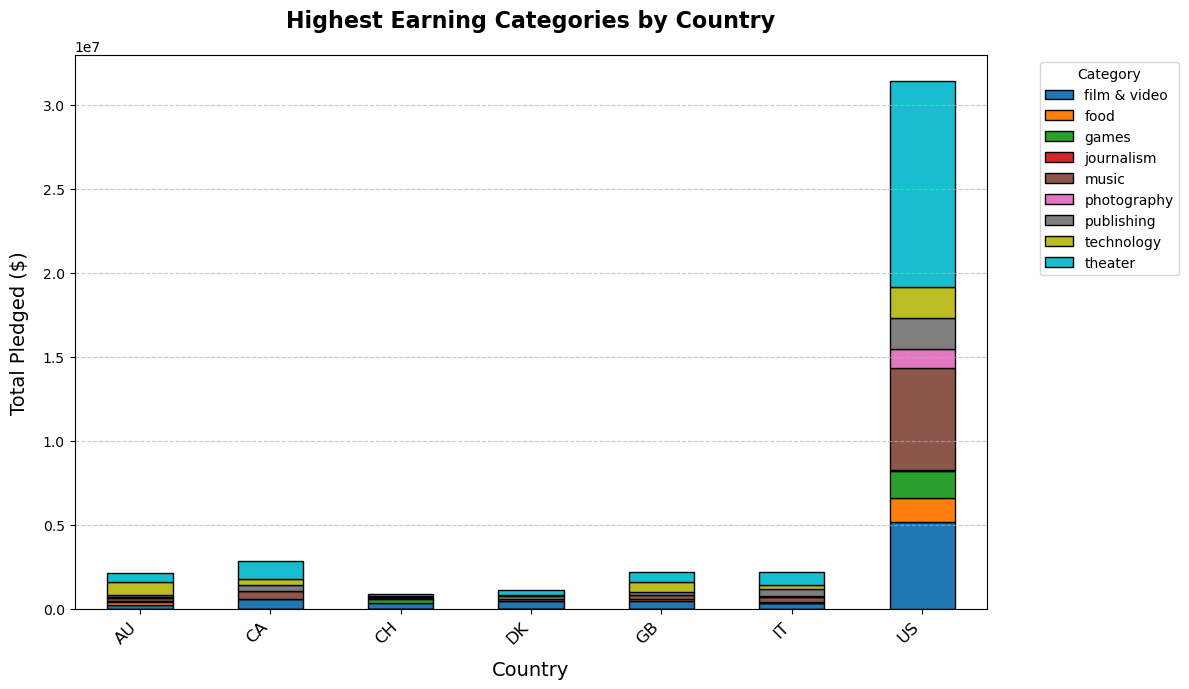

In [41]:
# Pivot the data for a stacked bar chart
pivot_df = df.pivot(index='country', columns='category_name', values='total_pledged').fillna(0)

# Plot the stacked bar chart
pivot_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    cmap='tab10', 
    edgecolor='black'
)

# Customize the chart
plt.title('Highest Earning Categories by Country', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country', fontsize=14, labelpad=10)
plt.ylabel('Total Pledged ($)', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Grid only on the y-axis

# Save the chart as an image file
plt.savefig('highest_earning_categories_by_country.png', dpi=300, bbox_inches='tight')

# Show the chart
plt.show()